In [4]:
!pip install -q sentence-transformers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.metrics.pairwise import cosine_similarity
import json
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


In [5]:
# # Load the cleaned ATS pairs dataset
df = pd.read_csv('cleaned_resumeJD_pairs.csv')

print(f'Loaded: {len(df)} pairs')
print(f'\nLabel distribution:')
print(df['match_label'].value_counts())
print(f'\nScore range: {df["match_score"].min()} to {df["match_score"].max()}')

df.head(3)

Loaded: 320 pairs

Label distribution:
match_label
High      115
Medium    105
Low       100
Name: count, dtype: int64

Score range: 50 to 94


,resume_text,job_description,match_score,match_label
0,"ARCHIT KUMAR SAVITA\nKanpur, Uttar Pradesh, In...",Machine Learning Engineer Python Scikit-learn ...,57,Medium
1,Sample Resume Software Engineer Applicant 1,Data Scientist SQL Python Engineering Analytic...,63,High
2,Sample Resume Software Engineer Applicant 2,Full Stack Developer React Node.js Express Mon...,58,High


In [6]:
# 1. Dataset ko split karna (Train: 70%, Temp: 30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['match_label']
)

# 2. Temp dataset ko equal validation aur test mein todna (Val: 15%, Test: 15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['match_label']
)

print(f'Train:      {len(train_df)} pairs')
print(f'Validation: {len(val_df)} pairs')
print(f'Test:       {len(test_df)} pairs')
print()

# Verify each split has all 3 labels
for name, split in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f'{name} label dist: {split["match_label"].value_counts().to_dict()}')

Train:      224 pairs
Validation: 48 pairs
Test:       48 pairs

Train label dist: {'High': 80, 'Medium': 74, 'Low': 70}
Validation label dist: {'High': 17, 'Medium': 16, 'Low': 15}
Test label dist: {'High': 18, 'Low': 15, 'Medium': 15}


In [7]:
# #Convert to InputExample format - sentence-transformers expects this
# #text1 = resume, text2 = job description, label = match_score (float 0 to 1)

train_examples = [
    InputExample(
        texts=[row['resume_text'], row['job_description']],
        label=float(row['match_score'] / 100)  # 100 se divide kiya scale match karne ke liye
    ) for _, row in train_df.iterrows()
]

val_examples = [
    InputExample(
        texts=[row['resume_text'], row['job_description']],
        label=float(row['match_score'] / 100)  # Same scale validation ke liye bhi
    ) for _, row in val_df.iterrows()
]

print(f'Train examples: {len(train_examples)}')
print(f'Val examples:   {len(val_examples)}')

print('\nSample InputExample:')
print(f'  text1 (resume): {train_examples[0].texts[0][:60]}...')
print(f'  text2 (JD):     {train_examples[0].texts[1][:60]}...')
print(f'  label:          {train_examples[0].label}')

Train examples: 224
Val examples:   48

Sample InputExample:
  text1 (resume): Sample Resume Software Engineer Applicant 293...
  text2 (JD):     Full Stack Developer React Node.js Express MongoDB JavaScrip...
  label:          0.51


In [8]:
print('Loading base BERT model...')

base_model = SentenceTransformer('all-mpnet-base-v2')

print('Model loaded successfully!')

Loading base BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


In [9]:
# # Evaluate base model on test set BEFORE fine-tuning
# # This is our baseline, fine-tuning should beat this

print('Evaluating base model on test set...')
base_preds = []

for _, row in test_df.iterrows():
    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])
    sim = cosine_similarity([emb1], [emb2])[0][0]
    base_preds.append(float(sim))

# Scale correction: test_df['match_score'] ko 100 se divide kiya hai
base_mae = mean_absolute_error(test_df['match_score'] / 100, base_preds)
base_rmse = np.sqrt(mean_squared_error(test_df['match_score'] / 100, base_preds))

print(f'\nBase Model - Test Set Performance')
print(f'  MAE:  {base_mae:.4f}')
print(f'  RMSE: {base_rmse:.4f}')

Evaluating base model on test set...

Base Model - Test Set Performance
  MAE:  0.4483
  RMSE: 0.4615


In [10]:
model=SentenceTransformer('all-mpnet-base-v2')
train_dataloader=DataLoader(train_examples,shuffle=True,batch_size=16)
train_loss=losses.CosineSimilarityLoss(model)

evaluator=EmbeddingSimilarityEvaluator.from_input_examples(val_examples,name='sts-val')

print('Training setup ready')
print(f' Batch size:16')
print(f'Train pairs:{len(train_examples)}')
print(f'Steps/epoch:{len(train_dataloader)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training setup ready
 Batch size:16
Train pairs:224
Steps/epoch:14


In [12]:
# 1. Loss function define karna
train_loss = losses.CosineSimilarityLoss(model=base_model)

# 2. Evaluator set karna validation data check karne ke liye
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples,
    name='ats-validation'
)

# 3. Dataloader pipeline ready karna
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# 4. Training steps calculate karna
total_steps = len(train_dataloader) * 10
warmup_steps = int(total_steps * 0.1)

print(f'Total steps:  {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print('\nStarting fine-tuning on T4 GPU...\n')

# 5. Model Training Loop (save_steps hata diya hai)
base_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=int(len(train_dataloader) * 0.25),
    warmup_steps=warmup_steps,
    output_path='models/finetuned-ats-bert',
    save_best_model=True,
    use_amp=True,          # T4 GPU par training super fast karega
    show_progress_bar=True
)

print('\n--- FINE TUNING COMPLETE ---')


Total steps:  140
Warmup steps: 14

Starting fine-tuning on T4 GPU...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-validation Pearson Cosine,Ats-validation Spearman Cosine
3,No log,No log,-0.096168,-0.090072
6,No log,No log,-0.153318,-0.096971
9,No log,No log,-0.168895,-0.200190
12,No log,No log,-0.150991,-0.163303
14,No log,No log,-0.077440,-0.077903
15,No log,No log,-0.066107,-0.058129
18,No log,No log,-0.095009,-0.155100
21,No log,No log,-0.112331,-0.141953
24,No log,No log,-0.120544,-0.133207
27,No log,No log,-0.056082,-0.092843


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


--- FINE TUNING COMPLETE ---


In [13]:
# Fine-tuned model ko sahi saved directory se load karna
finetuned_model = SentenceTransformer('models/finetuned-ats-bert')

print('Fine-tuned model loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [14]:
ft_preds = []
for _, row in test_df.iterrows():
    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])
    sim = cosine_similarity([emb1], [emb2])[0][0]
    ft_preds.append(float(sim))

# Scale correction applied here: test_df['match_score'] / 100
ft_mae = mean_absolute_error(test_df['match_score'] / 100, ft_preds)
ft_rmse = np.sqrt(mean_squared_error(test_df['match_score'] / 100, ft_preds))

print(f'\nFine-tuned Model - Test Set Performance')
print(f'  MAE:  {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')

# Apne purane base model ke metrics ke sath compare karne ke liye yeh print statements:
print(f'\nComparison with Base Model:')
print(f'  MAE Change:  {base_mae:.4f} -> {ft_mae:.4f} (Lower is better)')
print(f'  RMSE Change: {base_rmse:.4f} -> {ft_rmse:.4f} (Lower is better)')


Fine-tuned Model - Test Set Performance
  MAE:  0.0987
  RMSE: 0.1158

Comparison with Base Model:
  MAE Change:  0.4483 -> 0.0987 (Lower is better)
  RMSE Change: 0.4615 -> 0.1158 (Lower is better)


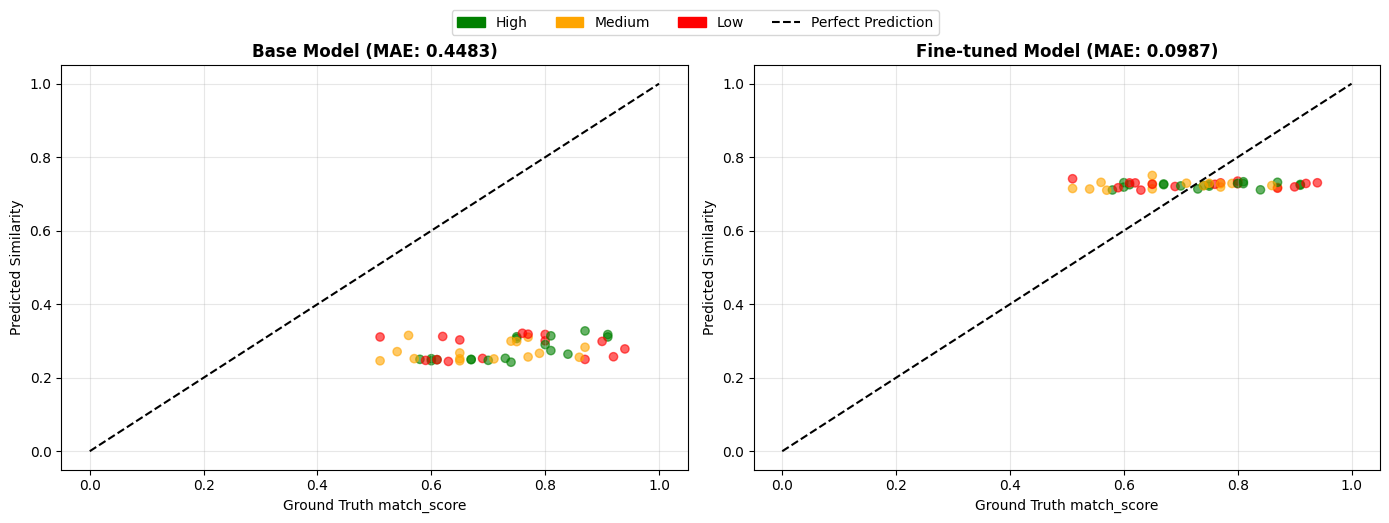

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# # Scatter plots: base vs fine-tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Case sensitivity match karne ke liye labels Capital letters mein map kiye hain
colors = test_df['match_label'].map({'Low': 'red', 'Medium': 'orange', 'High': 'green'})

# Dono plots ke upar loop chalana (Base model vs Fine-tuned model)
for ax, preds, title, mae in [
    (axes[0], base_preds, 'Base Model', base_mae),
    (axes[1], ft_preds, 'Fine-tuned Model', ft_mae)
]:
    # Ground Truth score ko 100 se divide kiya scale match karne ke liye
    ax.scatter(test_df['match_score'] / 100, preds, c=colors, alpha=0.6)

    # Perfect prediction wali diagonal line
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect')

    ax.set_xlabel('Ground Truth match_score')
    ax.set_ylabel('Predicted Similarity')
    ax.set_title(f'{title} (MAE: {mae:.4f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

# Legend Setup (Custom Patches)
legend_handles = [
    Patch(color='green', label='High'),
    Patch(color='orange', label='Medium'),
    Patch(color='red', label='Low'),
    Line2D([0], [0], color='black', linestyle='--', label='Perfect Prediction')
]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)

plt.tight_layout()
plt.show()

In [17]:
import json

# # Creating experiment metadata for logging
metadata = {
    'base_model':    'all-mpnet-base-v2',
    'dataset':       'cleaned_resumeJD_pairs.csv',
    'total_pairs':   len(df),
    'train_pairs':   len(train_df),
    'val_pairs':     len(val_df),
    'test_pairs':    len(test_df),
    'epochs':        10,
    'batch_size':    16,
    'base_mae':      round(float(base_mae), 4),
    'finetuned_mae': round(float(ft_mae), 4),
    'base_rmse':     round(float(base_rmse), 4),
    'finetuned_rmse':round(float(ft_rmse), 4)
}


with open('models/finetuned-ats-bert/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved successfully inside models directory!")
print("-" * 50)

# Metadata dictionary ko pretty print karke check karna
print(json.dumps(metadata, indent=4))

Metadata saved successfully inside models directory!
--------------------------------------------------
{
    "base_model": "all-mpnet-base-v2",
    "dataset": "cleaned_resumeJD_pairs.csv",
    "total_pairs": 320,
    "train_pairs": 224,
    "val_pairs": 48,
    "test_pairs": 48,
    "epochs": 10,
    "batch_size": 16,
    "base_mae": 0.4483,
    "finetuned_mae": 0.0987,
    "base_rmse": 0.4615,
    "finetuned_rmse": 0.1158
}


In [18]:
# #Production Pipeline Test

def score_resume_against_jd(resume_text, jd_text, model):
    # Dono inputs ko numpy arrays mein convert karke encode karna
    emb_resume = model.encode(resume_text, convert_to_numpy=True)
    emb_jd     = model.encode(jd_text, convert_to_numpy=True)

    # Cosine similarity matrix se float score nikalna
    score      = cosine_similarity([emb_resume], [emb_jd])[0][0]
    return float(score)


# # Test with realistic cases
test_cases = [
    {
        'label':  'HIGH match expected',
        'resume': 'Senior Python developer with 5+ years experience building REST APIs with Django and Flask.',
        'jd':     'We need a Python Software Engineer to build scalable backend services using Django REST framework.'
    },
    {
        'label':  'MEDIUM match expected',
        'resume': 'Frontend developer specialized in React, JavaScript, and CSS with basic knowledge of Node.js backend.',
        'jd':     'Full Stack Web Developer proficient in React for frontend and Python/Django for server-side engineering.'
    },
    {
        'label':  'LOW match expected',
        'resume': 'Executive Chef with Michelin star restaurant management experience, culinary arts expert.',
        'jd':     'Data Scientist with strong machine learning fundamentals, PyTorch, and deep learning knowledge.'
    }
]

# Ab functional testing loop chalate hain dono models par compare karne ke liye
print("Testing custom pipeline...\n")
for case in test_cases:
    print(f"Scenario: {case['label']}")

    # 1. Base Model Prediction
    base_score = score_resume_against_jd(case['resume'], case['jd'], base_model)

    # 2. Fine-tuned Model Prediction
    ft_score   = score_resume_against_jd(case['resume'], case['jd'], finetuned_model)

    print(f"  -> Base Model Similarity:       {base_score:.4f}")
    print(f"  -> Fine-tuned Model Similarity:  {ft_score:.4f}\n")

Testing custom pipeline...

Scenario: HIGH match expected
  -> Base Model Similarity:       0.8624
  -> Fine-tuned Model Similarity:  0.8696

Scenario: MEDIUM match expected
  -> Base Model Similarity:       0.9154
  -> Fine-tuned Model Similarity:  0.9150

Scenario: LOW match expected
  -> Base Model Similarity:       0.6757
  -> Fine-tuned Model Similarity:  0.6772

